# Module 5, Class 2: DBSCAN Comparison

**Student:** Firdavs Boliev

This notebook compares K-Means, DBSCAN, and Agglomerative Clustering on moon-shaped data.


In [1]:
# Import clustering tools and set a random seed for repeatable results.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

np.random.seed(42)


## 1. Generate Crescent-Shaped Data

`make_moons` creates two interleaving half-circles. This is a classic example where centroid-based methods struggle.

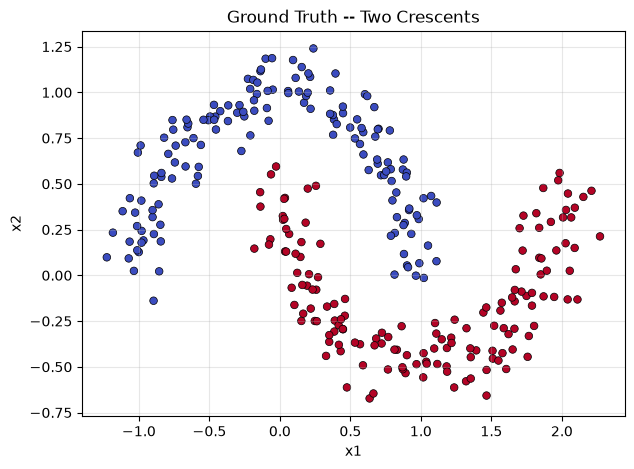

In [2]:
# Create moon-shaped data where the true clusters are curved.
X, y_true = make_moons(n_samples=300, noise=0.1, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)
plt.title('Ground Truth -- Two Crescents')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.show()


## 2. K-Means (k=2) -- The Failure Case

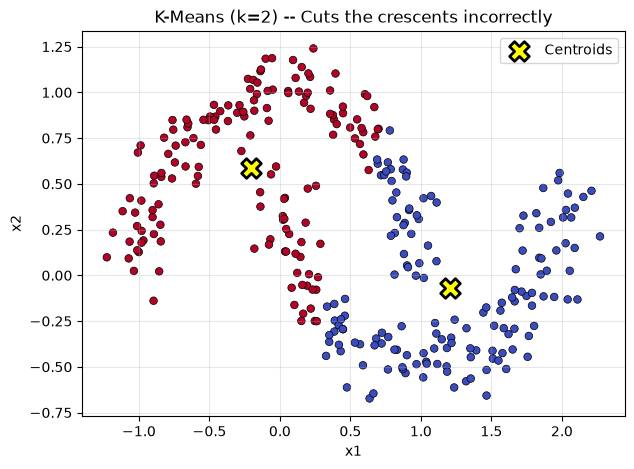

In [3]:
# Run K-Means with two clusters to show its limitation on curved data.
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=km_labels, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', marker='X', edgecolors='black', linewidths=2, label='Centroids')
plt.title('K-Means (k=2) -- Cuts the crescents incorrectly')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


K-Means draws a straight line between centroids. It cannot capture the curved shape of the crescents.

## 3. DBSCAN -- Density-Based Clustering

**Key parameters:**
- `eps`: maximum distance between two points to be considered neighbors
- `min_samples`: minimum number of points in a neighborhood to form a core point

DBSCAN does not require you to specify k. It discovers clusters based on density.

DBSCAN found 2 clusters and 0 noise points


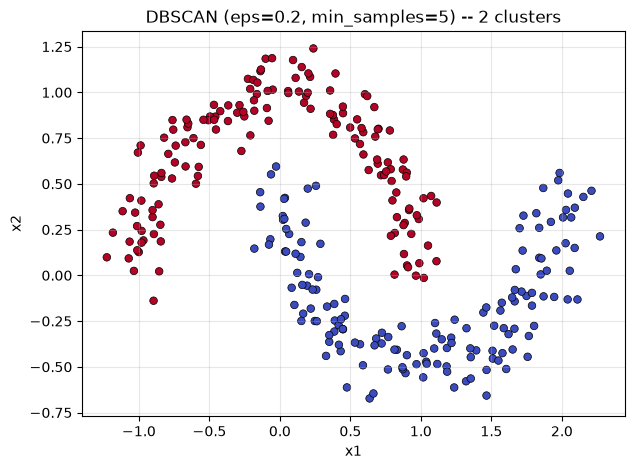

In [4]:
# Run DBSCAN to find density-based clusters without choosing k.
dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X)

n_clusters = len(set(db_labels) - {-1})
n_noise = (db_labels == -1).sum()
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points")

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=db_labels, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)
# Mark noise points
noise_mask = db_labels == -1
if noise_mask.any():
    plt.scatter(X[noise_mask, 0], X[noise_mask, 1], c='gray', s=30, marker='x', label='Noise')
    plt.legend()
plt.title(f'DBSCAN (eps=0.2, min_samples=5) -- {n_clusters} clusters')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.show()


## 4. Agglomerative Clustering

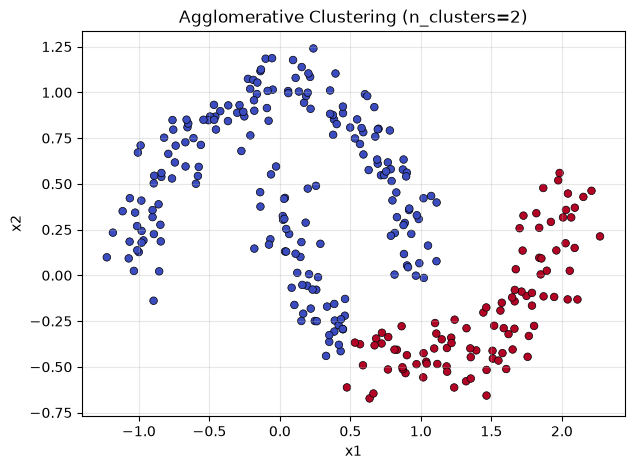

In [5]:
# Run Agglomerative Clustering as another comparison method.
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=agg_labels, cmap='coolwarm', s=30, edgecolors='black', linewidths=0.5)
plt.title('Agglomerative Clustering (n_clusters=2)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.show()


## 5. Side-by-Side Comparison

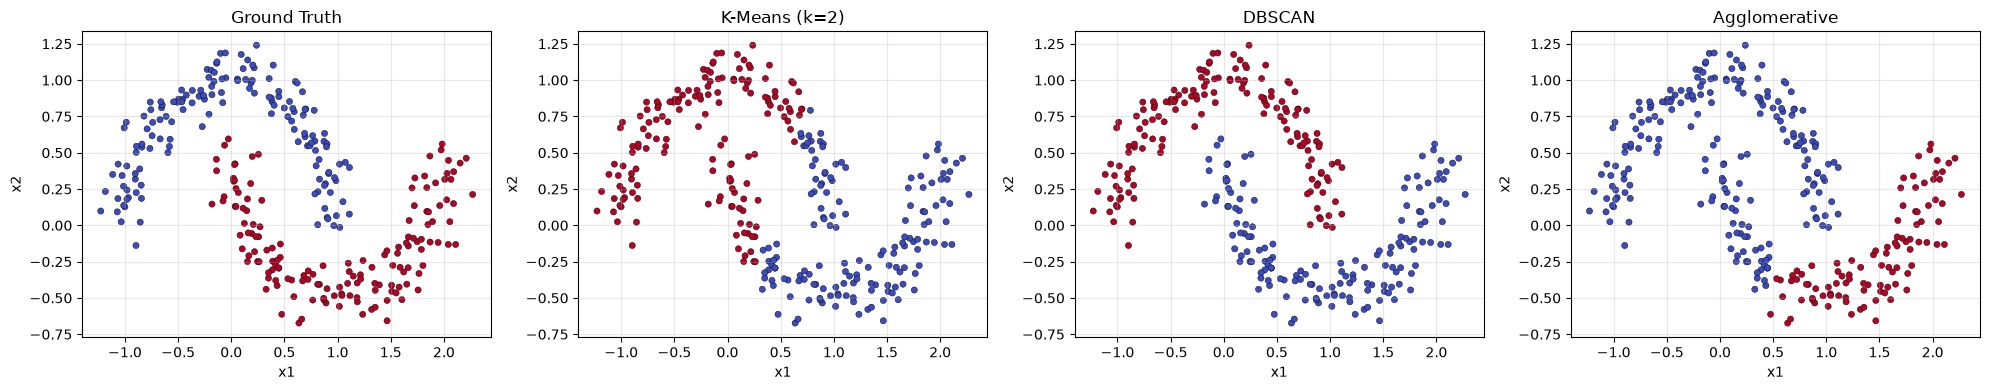

In [6]:
# Plot all clustering results side by side for an easy visual comparison.
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

titles = ['Ground Truth', 'K-Means (k=2)', 'DBSCAN', 'Agglomerative']
all_labels = [y_true, km_labels, db_labels, agg_labels]

for ax, title, lbls in zip(axes, titles, all_labels):
    ax.scatter(X[:, 0], X[:, 1], c=lbls, cmap='coolwarm', s=20, edgecolors='black', linewidths=0.3)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

| Method | Needs k? | Handles Non-Spherical? | Handles Noise? |
|--------|----------|----------------------|----------------|
| K-Means | Yes | No | No |
| DBSCAN | No | Yes | Yes (marks as -1) |
| Agglomerative | Yes | Depends on linkage | No |

---

## Student Work

### Explain WHY K-Means fails on this data

In the cell below, write a clear explanation covering:
1. What assumption does K-Means make about cluster shapes?
2. Why does that assumption break for crescent/moon-shaped data?
3. How does DBSCAN avoid this problem?
4. In what scenario would you still prefer K-Means over DBSCAN?

### Explanation Answer

1. K-Means assumes clusters are roughly round or spherical around a center point.
2. This breaks for crescent-shaped data because each real cluster is curved, so one straight centroid-based split cuts through the moons incorrectly.
3. DBSCAN avoids this problem by grouping dense neighboring points together, so it can follow curved shapes and mark isolated points as noise.
4. I would still prefer K-Means when the data is large, numeric, scaled, and the groups are compact and roughly round.